# **ENUNCIADO**

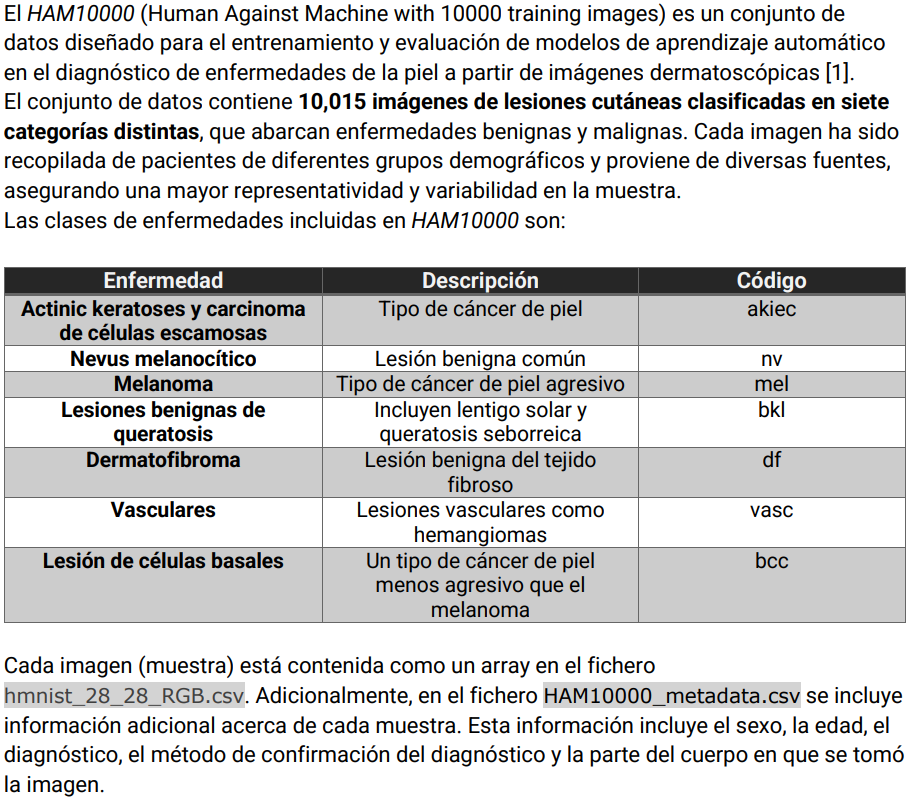

## **TAREA**

Se propone que el alumno diseñe, implemente y evalúe diferentes modelos predictivos basados en redes neuronales profundas de cara a resolver el problema de clasificación multiclase propuesto.

### 0 - Carga y preprocesamiento de datos

In [1]:
import tensorflow as tf
print("GPUs detectadas:", len(tf.config.list_physical_devices('GPU')))

GPUs detectadas: 1


In [2]:
import os
import sys
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Flatten, Dropout, Conv2D, BatchNormalization, Activation, GlobalMaxPooling2D, Concatenate, GlobalAveragePooling2D, Resizing, Lambda, Add)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.utils import plot_model
import urllib
import cv2

In [3]:
# --- Carga de los CSV ---
df_metadata = pd.read_csv('HAM10000_metadata.csv')
df_rgb = pd.read_csv('hmnist_28_28_RGB.csv')

print('df_metadata:', df_metadata.shape)
# Los 2353, son los 28x28x3
print('df_rgb:', df_rgb.shape)

df_metadata: (10015, 7)
df_rgb: (10015, 2353)


In [4]:
# Preprocesado de los datos tabulares
df = df_metadata.copy()
df['age'] = df['age'].fillna(df['age'].median())
# Normalización a rango [0,1]
df['age'] = df['age'] / 100.0

# One-hot encoding de variables categóricas con pandas.
# Generará columnas nuevas por cada categoría única que exista dentro de
# sex y localization
df_tab = pd.get_dummies(df[['sex', 'localization']], drop_first=False)
df_tab['age'] = df['age'].values

# X_tab, es una representación numérica de los datos procesados.
# Es un array de numpy que contiene:
#   - Las columnas de one-hot encoding para 'sex' (sex_female, sex_male, sex_unknown).
#   - Las columnas de one-hot encoding para 'localization' (las diferentes partes del cuerpo).
#   - La columna de 'age' normalizada.
X_tab = df_tab.values.astype(np.float32)
print('X_tab.shape:', X_tab.shape)

X_tab.shape: (10015, 19)


In [5]:
# HE IDO SIGUIENDO LA LÓGICA DEL EJERCICIO DESARROLLADO A TRAVES DE UN DATASET
# REAL EN KAGGLE EN EL NOTEBOOK DE FUSION
# Creamos la lista classes:
# Con (df['dx'].unique()), seleccionamos los datos unicos de la columna dx de df.
# Con sorted, los ordenamos alfabeticamente.
classes = sorted(df['dx'].unique())

# Generamos el diccionario class_to_idx asignado un numero, empezando desde 0,
# a cada una de las clases incluidas en la lista classes.
class_to_idx = {c: i for i, c in enumerate(classes)}

# Generamos y_int donde la función .map, mira el valor de df['dx'], busca en el
# diccionario la equivalencia numérica, y la sustituye.
y_int = df['dx'].map(class_to_idx).values.astype('int32')
n_classes = len(classes)

# Lo pasamos a categorico
Y = to_categorical(y_int, num_classes=n_classes)
print('Clases:', classes)
print("class_to_idx", class_to_idx)
print("y_int", y_int)
print('Y.shape:', Y.shape, ' (one-hot)')

Clases: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
class_to_idx {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
y_int [2 2 2 ... 0 0 4]
Y.shape: (10015, 7)  (one-hot)


X_img.shape: (10015, 28, 28, 3)


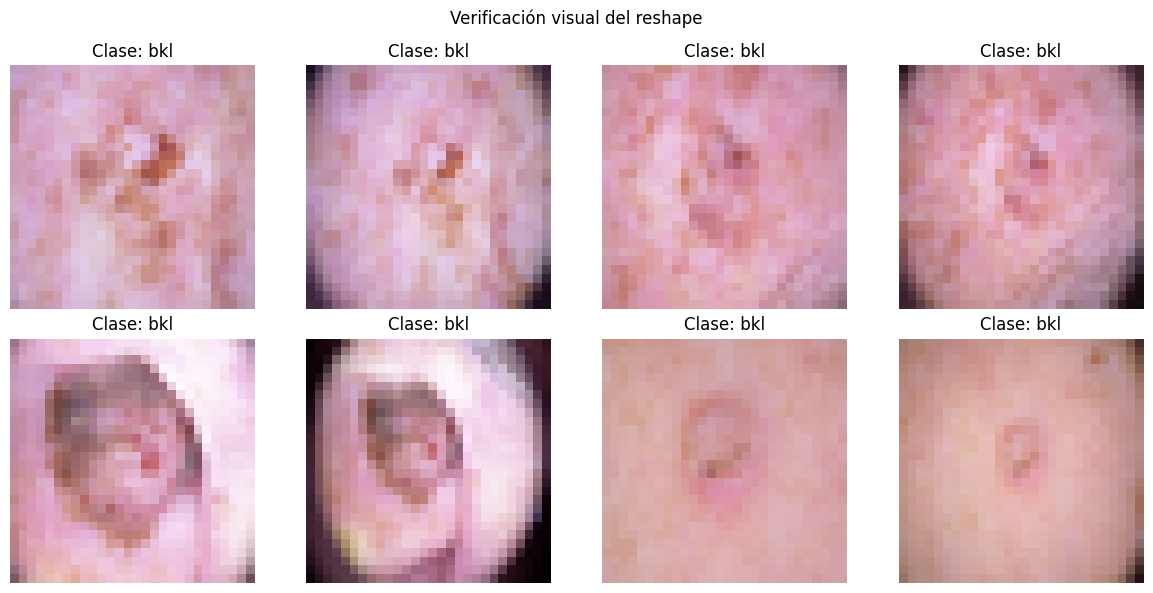

In [6]:
# Preprocesamiento de imágenes
# df_rgb, tiene una columna label, la cual ya hemos procesado anteriormente.
# la quitamos
X_img_label = df_rgb.drop(columns='label').values
# Ahora hacemos el reshape
X_img = X_img_label.reshape(-1, 28, 28, 3).astype(np.float32)

print('X_img.shape:', X_img.shape)

# Verificación visual
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_img[i]/255.0)
    ax.set_title(f'Clase: {classes[y_int[i]]}')
    ax.axis('off')
plt.suptitle('Verificación visual del reshape')
plt.tight_layout()
plt.show()

In [7]:
# Con indices, genero un array de numpy el cual contiene una secuencia de números
# enteros de 0 a len(Y) - 1

indices = np.arange(len(Y))

# El utilizar indices como referencia, hace que tanto el train, val y test para
# los datos tabulares y las imágenes, sean consistentes y que no se dividan de
# dos maneras diferentes para cada tipo de dato.

idx_train, idx_test = train_test_split(indices, test_size=0.2, stratify=y_int, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.2, stratify=y_int[idx_train], random_state=42)

X_tab_train, X_tab_val, X_tab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_test]
X_img_train, X_img_val, X_img_test = X_img[idx_train], X_img[idx_val], X_img[idx_test]

# Contiene las etiquetas one-hoy encoded
# Esto es un vector binario (por ejemplo, [0, 0, 1, 0, 0, 0, 0] para la clase 2).

Y_train, Y_val, Y_test = Y[idx_train], Y[idx_val], Y[idx_test]

# Contiene las etiquetas en formato entero
# (por ejemplo, 2 para la clase 2)
y_train_int, y_val_int, y_test_int = y_int[idx_train], y_int[idx_val], y_int[idx_test]

print(f'Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}')
print(len(idx_train)+len(idx_val)+len(idx_test))

Train: 6409 | Val: 1603 | Test: 2003
10015


In [8]:
print(n_classes)

7


### 1 - Modelo 1D (tabular): Resolver el problema considerando únicamente la información presente en los datos tabulares (sexo, edad, parte del cuerpo).

In [9]:
# Construyo la Red Neuronal para los datos tabulares
# Uso la API funcional
tab_in = Input(shape=(X_tab_train.shape[1],))
h0 = Dense(128, activation='relu')(tab_in)
h1 = Dense(128, activation='selu')(h0)
h2 = Dense(128, activation='relu')(h1)
h3 = Dense(128, activation='selu', name = "tabular_features")(h2)
tab_out = Dense(n_classes, activation='softmax')(h3)
tabular_model = Model(inputs=tab_in, outputs=tab_out)
tabular_model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 19)]              0         
                                                                 
 dense (Dense)               (None, 128)               2560      
                                                                 
 dense_1 (Dense)             (None, 128)               16512     
                                                                 
 dense_2 (Dense)             (None, 128)               16512     
                                                                 
 tabular_features (Dense)    (None, 128)               16512     
                                                                 
 dense_3 (Dense)             (None, 7)                 903       
                                                                 
Total params: 52,999
Trainable params: 52,999
Non-trainable p

In [10]:
#Definición de hiperparámetros
lr = 0.0001
epoches = 30
batch = 8

In [11]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)
tabular_model.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
H_tab = tabular_model.fit(X_tab_train, Y_train, validation_data=(X_tab_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/30
802/802 [==============================] - 5s 4ms/step - loss: 1.0490 - accuracy: 0.6829 - val_loss: 0.9394 - val_accuracy: 0.6974
Epoch 2/30
802/802 [==============================] - 3s 4ms/step - loss: 0.9366 - accuracy: 0.6982 - val_loss: 0.9038 - val_accuracy: 0.6999
Epoch 3/30
802/802 [==============================] - 3s 4ms/step - loss: 0.9166 - accuracy: 0.6989 - val_loss: 0.8951 - val_accuracy: 0.7024
Epoch 4/30
802/802 [==============================] - 3s 3ms/step - loss: 0.9113 - accuracy: 0.6984 - val_loss: 0.8897 - val_accuracy: 0.6999
Epoch 5/30
802/802 [==============================] - 3s 4ms/step - loss: 0.9056 - accuracy: 0.6984 - val_loss: 0.8894 - val_accuracy: 0.6999
Epoch 6/30
802/802 [==============================] - 3s 4ms/step - loss: 0.9027 - accuracy: 0.6971 - val_loss: 0.8936 - val_accuracy: 0.7049
Epoch 7/30
802/802 [==============================] - 3s 3ms/step - loss: 0.8995 - accuracy: 0.6990 - val_loss: 0.8864 - val_accuracy: 0.7012
Epoch 

In [13]:
pred = tabular_model.predict(X_tab_val)

51/51 [==============================] - 0s 1ms/step


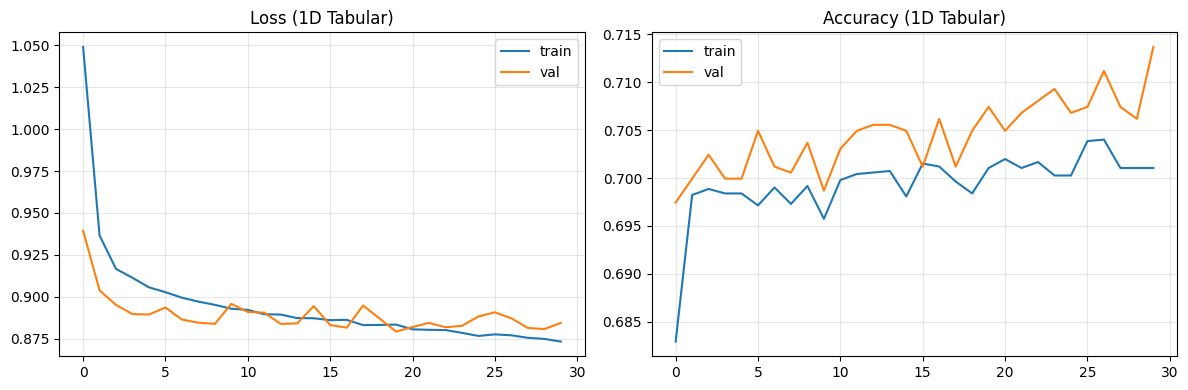

In [14]:
# Dibujo las curvas de entrenamiento para Loss y Accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_tab.history['loss'], label='train')
axes[0].plot(H_tab.history['val_loss'], label='val')
axes[0].set_title('Loss (1D Tabular)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_tab.history['accuracy'], label='train')
axes[1].plot(H_tab.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (1D Tabular)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2 - Modelo 2D (imágenes): Resolver el problema considerando la información presente en las imágenes empleando para ello al menos una red convolucional.

In [15]:
mean_per_channel = (X_img_train/255).mean(axis=(0, 1, 2))

In [16]:
dropout_rate = 0.6

img_in = Input(shape=(28, 28, 3), name='img_in')
x = img_in/255
# Usamos una capa Lambda para aplicar la resta de la media
x = Lambda(lambda image: image - mean_per_channel)(x)
x = Conv2D(32, kernel_size=(3, 3))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = Conv2D(64, kernel_size=(3, 3))(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)

x = GlobalMaxPooling2D()(x)
x = Flatten()(x)

x = Dense(1024, activation='relu', name = "vision_features")(x)
x = Dropout(dropout_rate)(x)

img_out = Dense(n_classes, activation='softmax', name='vision_output')(x)
vision_model_1 = Model(inputs=img_in, outputs=img_out)
vision_model_1.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 img_in (InputLayer)         [(None, 28, 28, 3)]       0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 28, 28, 3)        0         
 )                                                               
                                                                 
 lambda (Lambda)             (None, 28, 28, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 26, 26, 32)       128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 26, 26, 32)        0   

In [17]:
#Definición de hiperparámetros
lr = 0.001
epoches = 35
batch = 16

In [18]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [19]:
vision_model_1.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
H_vis_1 = vision_model_1.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/35
401/401 [==============================] - 6s 5ms/step - loss: 0.9850 - accuracy: 0.6570 - val_loss: 1.2708 - val_accuracy: 0.4841
Epoch 2/35
401/401 [==============================] - 2s 5ms/step - loss: 0.8689 - accuracy: 0.6817 - val_loss: 0.8275 - val_accuracy: 0.6931
Epoch 3/35
401/401 [==============================] - 2s 4ms/step - loss: 0.8151 - accuracy: 0.6971 - val_loss: 0.7954 - val_accuracy: 0.7118
Epoch 4/35
401/401 [==============================] - 2s 5ms/step - loss: 0.7826 - accuracy: 0.7082 - val_loss: 0.7095 - val_accuracy: 0.7374
Epoch 5/35
401/401 [==============================] - 2s 5ms/step - loss: 0.7596 - accuracy: 0.7177 - val_loss: 0.7262 - val_accuracy: 0.7199
Epoch 6/35
401/401 [==============================] - 2s 5ms/step - loss: 0.7397 - accuracy: 0.7254 - val_loss: 0.7383 - val_accuracy: 0.7112
Epoch 7/35
401/401 [==============================] - 2s 5ms/step - loss: 0.7390 - accuracy: 0.7288 - val_loss: 0.6825 - val_accuracy: 0.7480
Epoch 

In [21]:
pred_1 = vision_model_1.predict(X_img_val)

51/51 [==============================] - 0s 1ms/step


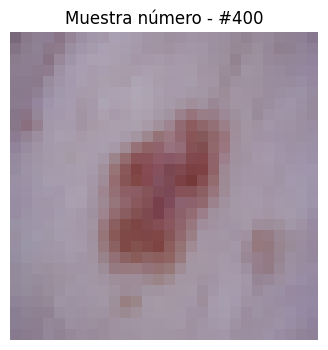

El modelo predice: nv
En realidad es:    nv


In [22]:
#HAGO UN COMPROBADOR (similar al que hay en el notebook del tema 3)

#Indico el índice para identificar la muestra
idx = 400

# Saco el vector de 7 probabilidades que el modelo asignó a idx
pred_probs = pred[idx]
# Saco el índice con el valor más alto (devuelve un nº entero)
pred_class_idx = np.argmax(pred_probs)
# Con ese entero, me voy a classes y saco el valor en texto.
pred_class_name = classes[pred_class_idx]

# La misma lógica para el conjunto de validación
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]


plt.figure(figsize=(4, 4))
plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

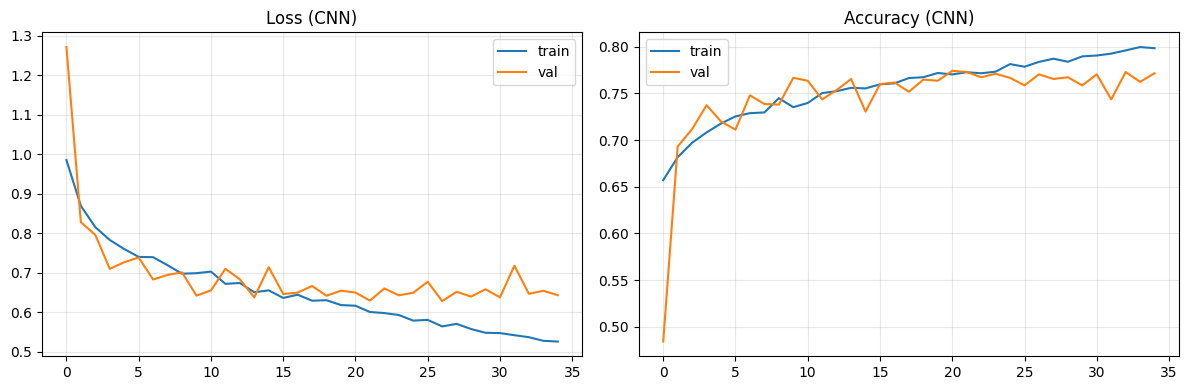

In [23]:
# Curvas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_1.history['loss'], label='train')
axes[0].plot(H_vis_1.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_1.history['accuracy'], label='train')
axes[1].plot(H_vis_1.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()



He hecho un modelo CNN manual para practicar y ahora, voy a pasar otros modelos de CNN (VGG16, RestNet50, InceptionV3)

### **VGG16**

In [24]:
from tensorflow.keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

In [25]:
feature_extractor = VGG16(weights="imagenet", include_top=False)
# significa que al cargar el modelo pre-entrenado InceptionV3,
# no estamos incluyendo las capas finales de clasificación que fueron entrenadas originalmente para ImageNet.
# En su lugar, obtenemos solo la base convolucional del modelo, que se encarga de extraer características de las imágenes.
# Esto es fundamental para el aprendizaje por transferencia,

In [26]:
feature_extractor.trainable = False

In [27]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 0.001
epoches = 25
batch = 16

In [28]:
img_in_2 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(224, 224)(img_in_2)

# Aplicar la capa Lambda para preprocesar la entrada de VGG16
x = Lambda(preprocess_input)(x)
# Extraer características con VGG16
image_features = feature_extractor(x, training = False)

x = GlobalAveragePooling2D()(image_features)
# Añadir capas densas para la clasificación
x = Dense(1024, activation='relu')(x)
x = Dropout(dropout_rate)(x)

x = Dense(1024, activation='relu', name="vision_features_VGG")(x)
x = Dropout(dropout_rate)(x)

img_out_2 = Dense(n_classes, activation='softmax', name='vision_output_vgg')(x)

vision_model_2 = Model(inputs=img_in_2, outputs=img_out_2)
vision_model_2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 3)]       0         
                                                                 
 resizing (Resizing)         (None, 224, 224, 3)       0         
                                                                 
 lambda_1 (Lambda)           (None, 224, 224, 3)       0         
                                                                 
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense_4 (Dense)             (None, 1024)              525312    
                                                           

In [29]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [30]:
vision_model_2.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [31]:
H_vis_2 = vision_model_2.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/25
401/401 [==============================] - 23s 50ms/step - loss: 1.1757 - accuracy: 0.6461 - val_loss: 0.7874 - val_accuracy: 0.7180
Epoch 2/25
401/401 [==============================] - 18s 44ms/step - loss: 0.8715 - accuracy: 0.6909 - val_loss: 0.7570 - val_accuracy: 0.7293
Epoch 3/25
401/401 [==============================] - 18s 45ms/step - loss: 0.8317 - accuracy: 0.7042 - val_loss: 0.7325 - val_accuracy: 0.7180
Epoch 4/25
401/401 [==============================] - 18s 45ms/step - loss: 0.7943 - accuracy: 0.7124 - val_loss: 0.7247 - val_accuracy: 0.7367
Epoch 5/25
401/401 [==============================] - 18s 45ms/step - loss: 0.7909 - accuracy: 0.7165 - val_loss: 0.7172 - val_accuracy: 0.7305
Epoch 6/25
401/401 [==============================] - 18s 45ms/step - loss: 0.7774 - accuracy: 0.7263 - val_loss: 0.6961 - val_accuracy: 0.7367
Epoch 7/25
401/401 [==============================] - 18s 45ms/step - loss: 0.7566 - accuracy: 0.7305 - val_loss: 0.7127 - val_accuracy:

In [32]:
pred_2 = vision_model_2.predict(X_img_val)

51/51 [==============================] - 7s 64ms/step


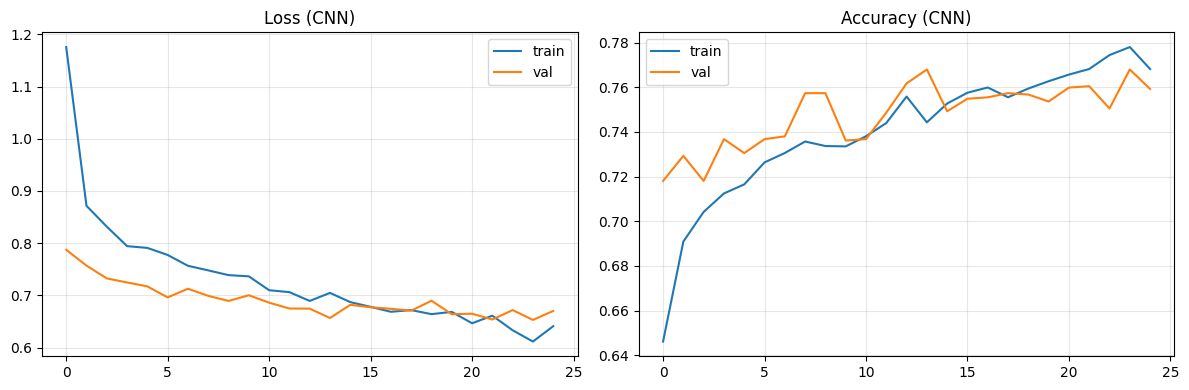

In [33]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_2.history['loss'], label='train')
axes[0].plot(H_vis_2.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_2.history['accuracy'], label='train')
axes[1].plot(H_vis_2.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

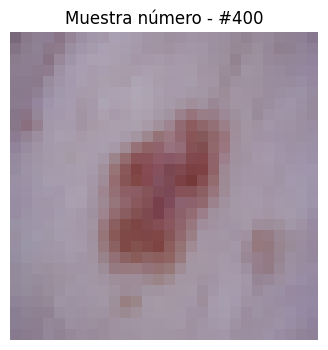

El modelo predice: nv
En realidad es:    nv


In [34]:
idx = 400
pred_probs = pred_2[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]
plt.figure(figsize=(4, 4))
plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### **Resnet**

In [35]:
from tensorflow.keras.applications import ResNet50

In [36]:
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions

In [37]:
feature_extractor2 = ResNet50(weights="imagenet", include_top=False)

In [38]:
feature_extractor2.trainable = False

In [39]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 0.001
epoches = 20
batch = 16

In [40]:
img_in_3 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(224, 224)(img_in_3)

# Extraer características con RestNet 50
x = Lambda(preprocess_input)(x)
image_features = feature_extractor2(x, training = False)

# Aplanar las características de RestNet 50
x = GlobalAveragePooling2D()(image_features)

# Añadir capas densas para la clasificación
x = Dense(1024, activation='selu', name = "vision_features_REST")(x)
x = Dropout(dropout_rate)(x)

img_out_3 = Dense(n_classes, activation='softmax')(x)

vision_model_3 = Model(inputs=img_in_3, outputs=img_out_3)
vision_model_3.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 28, 28, 3)]       0         
                                                                 
 resizing_1 (Resizing)       (None, 224, 224, 3)       0         
                                                                 
 lambda_2 (Lambda)           (None, 224, 224, 3)       0         
                                                                 
 resnet50 (Functional)       (None, None, None, 2048)  23587712  
                                                                 
 global_average_pooling2d_1   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 vision_features_REST (Dense  (None, 1024)             2098176   
 )                                                         

In [41]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [42]:
vision_model_3.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [43]:
H_vis_3 = vision_model_3.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/20
401/401 [==============================] - 17s 37ms/step - loss: 1.9810 - accuracy: 0.6521 - val_loss: 1.1397 - val_accuracy: 0.7424
Epoch 2/20
401/401 [==============================] - 13s 34ms/step - loss: 1.3062 - accuracy: 0.6909 - val_loss: 0.8857 - val_accuracy: 0.7480
Epoch 3/20
401/401 [==============================] - 13s 34ms/step - loss: 1.1591 - accuracy: 0.6995 - val_loss: 1.0366 - val_accuracy: 0.7187
Epoch 4/20
401/401 [==============================] - 14s 34ms/step - loss: 1.0133 - accuracy: 0.7248 - val_loss: 0.9407 - val_accuracy: 0.7261
Epoch 5/20
401/401 [==============================] - 14s 34ms/step - loss: 1.0006 - accuracy: 0.7173 - val_loss: 0.8711 - val_accuracy: 0.7604
Epoch 6/20
401/401 [==============================] - 14s 34ms/step - loss: 0.9503 - accuracy: 0.7223 - val_loss: 0.7256 - val_accuracy: 0.7686
Epoch 7/20
401/401 [==============================] - 14s 34ms/step - loss: 0.9023 - accuracy: 0.7352 - val_loss: 0.8512 - val_accuracy:

In [44]:
pred_3 = vision_model_3.predict(X_img_val)

51/51 [==============================] - 3s 42ms/step


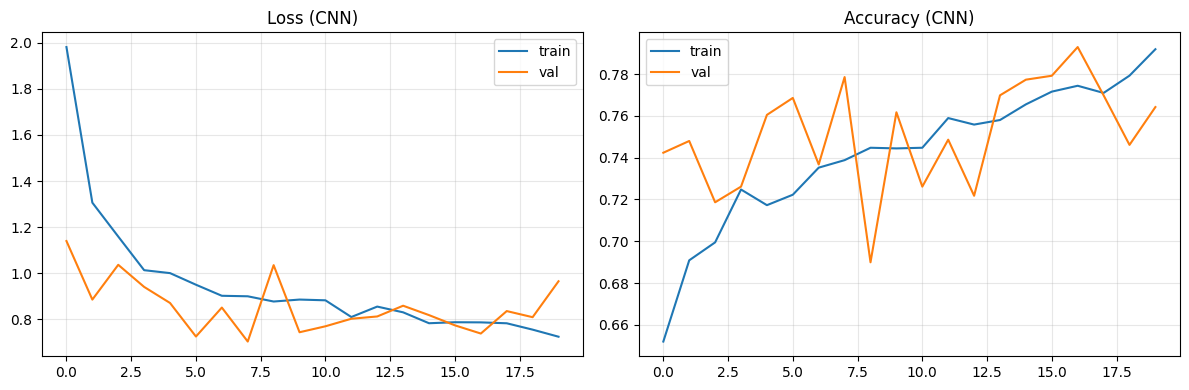

In [45]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_3.history['loss'], label='train')
axes[0].plot(H_vis_3.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_3.history['accuracy'], label='train')
axes[1].plot(H_vis_3.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

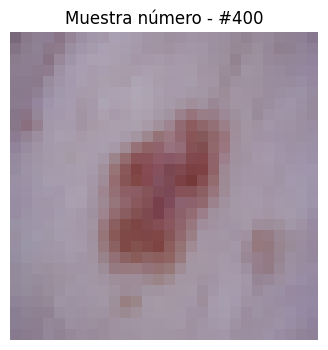

El modelo predice: nv
En realidad es:    nv


In [46]:
idx = 400
pred_probs = pred_3[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]

plt.figure(figsize=(4, 4))

plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### **Incention_v3**

In [47]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input

In [48]:
feature_extractor3 = InceptionV3(weights="imagenet", include_top=False)

In [49]:
feature_extractor3.trainable = False

In [50]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 0.001
epoches = 20
batch = 16

In [51]:
img_in_4 = Input(shape=(28, 28, 3))

# Aplicar la capa Resizing a la entrada
x = Resizing(299, 299)(img_in_4)

# Extraer características con VGG16
x = Lambda(preprocess_input)(x)
image_features = feature_extractor3(x, training = False)

# Aplanar las características de VGG16
x = GlobalAveragePooling2D()(image_features)

# Añadir capas densas para la clasificación
x = Dense(1024, activation='relu', name = "vision_features_Inc")(x)
x = Dropout(dropout_rate)(x)

img_out_4 = Dense(n_classes, activation='softmax')(x)

vision_model_4 = Model(inputs=img_in_4, outputs=img_out_4)
vision_model_4.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 28, 28, 3)]       0         
                                                                 
 resizing_2 (Resizing)       (None, 299, 299, 3)       0         
                                                                 
 lambda_3 (Lambda)           (None, 299, 299, 3)       0         
                                                                 
 inception_v3 (Functional)   (None, None, None, 2048)  21802784  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 vision_features_Inc (Dense)  (None, 1024)             2098176   
                                                           

In [52]:
optimizer = Adam(learning_rate=lr, beta_1=0.9, beta_2=0.999)

In [53]:
vision_model_4.compile(optimizer=Adam(learning_rate=lr), loss='categorical_crossentropy', metrics=['accuracy'])

In [54]:
H_vis_4 = vision_model_4.fit(X_img_train, Y_train, validation_data=(X_img_val, Y_val), epochs=epoches, batch_size=batch)

Epoch 1/20
401/401 [==============================] - 27s 59ms/step - loss: 1.0319 - accuracy: 0.6753 - val_loss: 0.8546 - val_accuracy: 0.7006
Epoch 2/20
401/401 [==============================] - 23s 56ms/step - loss: 0.8692 - accuracy: 0.6985 - val_loss: 0.8005 - val_accuracy: 0.7105
Epoch 3/20
401/401 [==============================] - 23s 56ms/step - loss: 0.8299 - accuracy: 0.7092 - val_loss: 0.7883 - val_accuracy: 0.7143
Epoch 4/20
401/401 [==============================] - 23s 57ms/step - loss: 0.8133 - accuracy: 0.7140 - val_loss: 0.7823 - val_accuracy: 0.7149
Epoch 5/20
401/401 [==============================] - 23s 56ms/step - loss: 0.7930 - accuracy: 0.7173 - val_loss: 0.7739 - val_accuracy: 0.7168
Epoch 6/20
401/401 [==============================] - 23s 56ms/step - loss: 0.7821 - accuracy: 0.7174 - val_loss: 0.7760 - val_accuracy: 0.7236
Epoch 7/20
401/401 [==============================] - 23s 57ms/step - loss: 0.7692 - accuracy: 0.7215 - val_loss: 0.7642 - val_accuracy:

In [55]:
pred_4 = vision_model_4.predict(X_img_val)

51/51 [==============================] - 5s 74ms/step


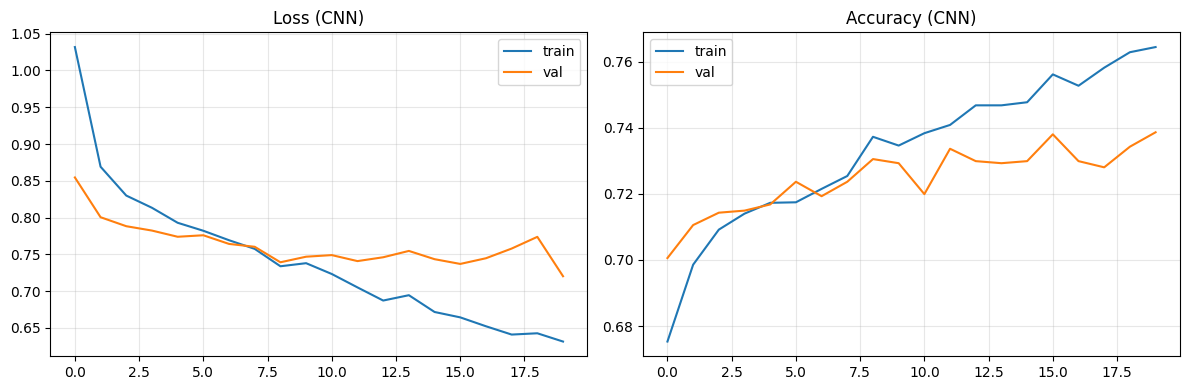

In [56]:
# Curvas train y validación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(H_vis_4.history['loss'], label='train')
axes[0].plot(H_vis_4.history['val_loss'], label='val')
axes[0].set_title('Loss (CNN)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(H_vis_4.history['accuracy'], label='train')
axes[1].plot(H_vis_4.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy (CNN)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

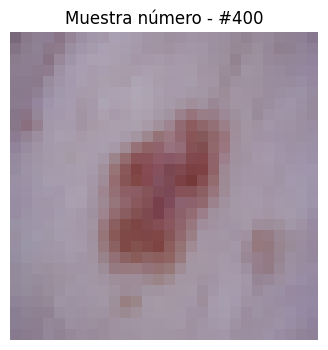

El modelo predice: nv
En realidad es:    nv


In [57]:
idx = 400
pred_probs = pred_4[idx]
pred_class_idx = np.argmax(pred_probs)
pred_class_name = classes[pred_class_idx]
true_class_idx = y_val_int[idx]
true_class_name = classes[true_class_idx]
plt.figure(figsize=(4, 4))

plt.imshow(X_img_val[idx] / 255.0)

plt.title(f"Muestra número - #{idx}")
plt.axis('off')
plt.show()

print(f"El modelo predice: {pred_class_name}")
print(f"En realidad es:    {true_class_name}")

### 3 - Estrategia late-fusion: Combinación aprendida de las predicciones realizadas por el modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [58]:
tabular_input_shape = (X_tab_train.shape[1],)
vision_input_shape = (28,28,3)

In [59]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 20
batch = 16

In [60]:
def build_late_fusion_model_1():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    # Congelamos los modelos ya entrenados
    tabular_model.trainable = False
    vision_model_1.trainable = False

    # TABULAR + CNN manual
    tabular_pred = tabular_model(tabular_input)
    vision_pred_1  = vision_model_1(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_1])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_1 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_1

In [61]:
model_lf_1 = build_late_fusion_model_1()
model_lf_1.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_1.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_8 (InputLayer)           [(None, 19)]         0           []                               
                                                                                                  
 input_9 (InputLayer)           [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model (Functional)             (None, 7)            52999       ['input_8[0][0]']                
                                                                                                  
 model_1 (Functional)           (None, 7)            93511       ['input_9[0][0]']                
                                                                                            

In [62]:
H_lf_1 = model_lf_1.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/20
401/401 [==============================] - 2s 4ms/step - loss: 1.6379 - accuracy: 0.2804 - val_loss: 1.5891 - val_accuracy: 0.6232
Epoch 2/20
401/401 [==============================] - 1s 3ms/step - loss: 1.5340 - accuracy: 0.6772 - val_loss: 1.4920 - val_accuracy: 0.6812
Epoch 3/20
401/401 [==============================] - 1s 3ms/step - loss: 1.4405 - accuracy: 0.6794 - val_loss: 1.4053 - val_accuracy: 0.6744
Epoch 4/20
401/401 [==============================] - 1s 3ms/step - loss: 1.3575 - accuracy: 0.6755 - val_loss: 1.3286 - val_accuracy: 0.6737
Epoch 5/20
401/401 [==============================] - 1s 3ms/step - loss: 1.2830 - accuracy: 0.6731 - val_loss: 1.2608 - val_accuracy: 0.6725
Epoch 6/20
401/401 [==============================] - 1s 3ms/step - loss: 1.2178 - accuracy: 0.6720 - val_loss: 1.2017 - val_accuracy: 0.6719
Epoch 7/20
401/401 [==============================] - 1s 3ms/step - loss: 1.1611 - accuracy: 0.6716 - val_loss: 1.1500 - val_accuracy: 0.6712
Epoch 

In [63]:
pred_lf_1 = model_lf_1.predict([X_tab_val, X_img_val])

51/51 [==============================] - 0s 2ms/step


In [64]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 1e-4
epoches = 25
batch = 16

In [65]:
def build_late_fusion_model_2():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_2.trainable = False

    # TABULAR + VGG16
    tabular_pred = tabular_model(tabular_input)
    vision_pred_2  = vision_model_2(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_2])
    x = Dense(32, activation="relu")(merged)
    x = Dropout(dropout_rate)(x)
    output = Dense(n_classes, activation="softmax")(x)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_2 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_2

In [66]:
model_lf_2 = build_late_fusion_model_2()
model_lf_2.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_2.summary()

Model: "model_6"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_10 (InputLayer)          [(None, 19)]         0           []                               
                                                                                                  
 input_11 (InputLayer)          [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model (Functional)             (None, 7)            52999       ['input_10[0][0]']               
                                                                                                  
 model_2 (Functional)           (None, 7)            16296775    ['input_11[0][0]']               
                                                                                            

In [67]:
H_lf_2 = model_lf_2.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/25
401/401 [==============================] - 19s 45ms/step - loss: 1.9858 - accuracy: 0.0947 - val_loss: 1.8462 - val_accuracy: 0.1179
Epoch 2/25
401/401 [==============================] - 18s 45ms/step - loss: 1.7482 - accuracy: 0.2930 - val_loss: 1.6058 - val_accuracy: 0.6687
Epoch 3/25
401/401 [==============================] - 18s 45ms/step - loss: 1.5175 - accuracy: 0.5949 - val_loss: 1.3653 - val_accuracy: 0.6694
Epoch 4/25
401/401 [==============================] - 18s 45ms/step - loss: 1.3201 - accuracy: 0.6623 - val_loss: 1.1631 - val_accuracy: 0.6694
Epoch 5/25
401/401 [==============================] - 18s 45ms/step - loss: 1.1623 - accuracy: 0.6697 - val_loss: 1.0342 - val_accuracy: 0.6694
Epoch 6/25
401/401 [==============================] - 18s 45ms/step - loss: 1.0701 - accuracy: 0.6755 - val_loss: 0.9580 - val_accuracy: 0.6694
Epoch 7/25
401/401 [==============================] - 18s 45ms/step - loss: 1.0217 - accuracy: 0.6781 - val_loss: 0.9089 - val_accuracy:

In [68]:
pred_lf_2 = model_lf_2.predict([X_tab_val, X_img_val])

51/51 [==============================] - 3s 66ms/step


In [69]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 25
batch = 16

In [70]:
def build_late_fusion_model_3():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_3.trainable = False

    # TABULAR + RESNET
    tabular_pred = tabular_model(tabular_input)
    vision_pred_3  = vision_model_3(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_3])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_3 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_3

In [71]:
model_lf_3 = build_late_fusion_model_3()
model_lf_3.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_3.summary()

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_12 (InputLayer)          [(None, 19)]         0           []                               
                                                                                                  
 input_13 (InputLayer)          [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model (Functional)             (None, 7)            52999       ['input_12[0][0]']               
                                                                                                  
 model_3 (Functional)           (None, 7)            25693063    ['input_13[0][0]']               
                                                                                            

In [72]:
H_lf_3 = model_lf_3.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/25
401/401 [==============================] - 16s 34ms/step - loss: 1.4833 - accuracy: 0.6708 - val_loss: 1.4332 - val_accuracy: 0.6681
Epoch 2/25
401/401 [==============================] - 13s 33ms/step - loss: 1.3968 - accuracy: 0.6706 - val_loss: 1.3529 - val_accuracy: 0.6687
Epoch 3/25
401/401 [==============================] - 13s 33ms/step - loss: 1.3160 - accuracy: 0.6706 - val_loss: 1.2825 - val_accuracy: 0.6706
Epoch 4/25
401/401 [==============================] - 13s 33ms/step - loss: 1.2478 - accuracy: 0.6723 - val_loss: 1.2225 - val_accuracy: 0.6706
Epoch 5/25
401/401 [==============================] - 13s 33ms/step - loss: 1.1941 - accuracy: 0.6716 - val_loss: 1.1709 - val_accuracy: 0.6719
Epoch 6/25
401/401 [==============================] - 13s 33ms/step - loss: 1.1410 - accuracy: 0.6703 - val_loss: 1.1265 - val_accuracy: 0.6712
Epoch 7/25
401/401 [==============================] - 13s 33ms/step - loss: 1.0980 - accuracy: 0.6705 - val_loss: 1.0884 - val_accuracy:

In [73]:
pred_lf_3 = model_lf_3.predict([X_tab_val, X_img_val])

51/51 [==============================] - 3s 43ms/step


In [74]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 25
batch = 8

In [75]:
def build_late_fusion_model_4():
    tabular_input = Input(shape=tabular_input_shape)
    vision_input  = Input(shape=vision_input_shape)

    tabular_model.trainable = False
    vision_model_4.trainable = False

    # TABULAR + INCEPTION
    tabular_pred = tabular_model(tabular_input)
    vision_pred_4  = vision_model_4(vision_input)

    # Fusión de las probabilidades concatenadas
    merged = Concatenate()([tabular_pred, vision_pred_4])
    output = Dense(n_classes, activation="softmax")(merged)

    # Definición final del modelo con nuevo classificador al final
    late_fusion_model_4 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return late_fusion_model_4

In [76]:
model_lf_4 = build_late_fusion_model_4()
model_lf_4.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_lf_4.summary()

Model: "model_8"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_14 (InputLayer)          [(None, 19)]         0           []                               
                                                                                                  
 input_15 (InputLayer)          [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model (Functional)             (None, 7)            52999       ['input_14[0][0]']               
                                                                                                  
 model_4 (Functional)           (None, 7)            23908135    ['input_15[0][0]']               
                                                                                            

In [77]:
H_lf_4 = model_lf_4.fit([X_tab_train, X_img_train], Y_train,validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size= batch)

Epoch 1/25
802/802 [==============================] - 30s 34ms/step - loss: 2.0846 - accuracy: 0.0527 - val_loss: 1.9670 - val_accuracy: 0.0667
Epoch 2/25
802/802 [==============================] - 26s 33ms/step - loss: 1.8644 - accuracy: 0.1286 - val_loss: 1.7617 - val_accuracy: 0.2470
Epoch 3/25
802/802 [==============================] - 26s 33ms/step - loss: 1.6726 - accuracy: 0.5310 - val_loss: 1.5856 - val_accuracy: 0.6326
Epoch 4/25
802/802 [==============================] - 26s 33ms/step - loss: 1.5113 - accuracy: 0.6655 - val_loss: 1.4387 - val_accuracy: 0.6694
Epoch 5/25
802/802 [==============================] - 26s 33ms/step - loss: 1.3748 - accuracy: 0.6728 - val_loss: 1.3186 - val_accuracy: 0.6694
Epoch 6/25
802/802 [==============================] - 26s 33ms/step - loss: 1.2667 - accuracy: 0.6717 - val_loss: 1.2231 - val_accuracy: 0.6694
Epoch 7/25
802/802 [==============================] - 26s 33ms/step - loss: 1.1802 - accuracy: 0.6706 - val_loss: 1.1481 - val_accuracy:

In [78]:
pred_lf_4 = model_lf_4.predict([X_tab_val, X_img_val])

51/51 [==============================] - 5s 75ms/step


### 4 - Estrategia early-fusion: Combinación aprendida de las características realizadas por el modelo 1D y el modelo 2D desarrollados previamente para resolver el problema.

In [79]:
tabular_input_shape = (X_tab_train.shape[1],)
vision_input_shape = (28,28,3)

In [80]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 0.003
epoches = 20
batch = 32

In [81]:
def build_early_fusion_model_1():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape)
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    # TABULAR + CNN manual
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_1.input, outputs=vision_model_1.get_layer('vision_features').output)

    tabular_model.trainable = False
    vision_model_1.trainable = False

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="selu")(merged)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_1 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_1

In [82]:
model_ef_1 = build_early_fusion_model_1()
model_ef_1.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_1.summary()

Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 19)]         0           []                               
                                                                                                  
 vision_input (InputLayer)      [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model_9 (Functional)           (None, 128)          52096       ['input_16[0][0]']               
                                                                                                  
 model_10 (Functional)          (None, 1024)         86336       ['vision_input[0][0]']           
                                                                                           

In [83]:
H_ef_1 = model_ef_1.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

Epoch 1/20
201/201 [==============================] - 2s 6ms/step - loss: 1.0073 - accuracy: 0.7053 - val_loss: 0.6234 - val_accuracy: 0.7804
Epoch 2/20
201/201 [==============================] - 1s 5ms/step - loss: 0.5783 - accuracy: 0.8009 - val_loss: 0.5952 - val_accuracy: 0.7941
Epoch 3/20
201/201 [==============================] - 1s 5ms/step - loss: 0.5083 - accuracy: 0.8181 - val_loss: 0.5927 - val_accuracy: 0.7979
Epoch 4/20
201/201 [==============================] - 1s 5ms/step - loss: 0.5009 - accuracy: 0.8231 - val_loss: 0.5694 - val_accuracy: 0.7998
Epoch 5/20
201/201 [==============================] - 1s 5ms/step - loss: 0.4702 - accuracy: 0.8327 - val_loss: 0.5667 - val_accuracy: 0.8010
Epoch 6/20
201/201 [==============================] - 1s 5ms/step - loss: 0.4573 - accuracy: 0.8332 - val_loss: 0.5715 - val_accuracy: 0.8047
Epoch 7/20
201/201 [==============================] - 1s 5ms/step - loss: 0.4547 - accuracy: 0.8338 - val_loss: 0.5660 - val_accuracy: 0.8110
Epoch 

In [84]:
pred_ef_1 = model_ef_1.predict([X_tab_val, X_img_val])

51/51 [==============================] - 0s 2ms/step


In [85]:
#Definición de hiperparámetros
dropout_rate = 0.5
lr = 1e-4
epoches = 25
batch = 16

In [86]:
def build_early_fusion_model_2():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_2.trainable = False

    # TABULAR + VGG16
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_2.input, outputs=vision_model_2.get_layer("vision_features_VGG").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="selu")(x)
    x = Dropout(dropout_rate)(x)
    
    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_2 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_2

In [87]:
model_ef_2 = build_early_fusion_model_2()
model_ef_2.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_2.summary()

Model: "model_14"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 tabular_input (InputLayer)     [(None, 19)]         0           []                               
                                                                                                  
 vision_input (InputLayer)      [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model_12 (Functional)          (None, 128)          52096       ['tabular_input[0][0]']          
                                                                                                  
 model_13 (Functional)          (None, 1024)         16289600    ['vision_input[0][0]']           
                                                                                           

In [88]:
H_ef_2 = model_ef_2.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

Epoch 1/25
401/401 [==============================] - 19s 45ms/step - loss: 0.9792 - accuracy: 0.6725 - val_loss: 0.6837 - val_accuracy: 0.7723
Epoch 2/25
401/401 [==============================] - 18s 44ms/step - loss: 0.7285 - accuracy: 0.7457 - val_loss: 0.6470 - val_accuracy: 0.7854
Epoch 3/25
401/401 [==============================] - 18s 45ms/step - loss: 0.6860 - accuracy: 0.7619 - val_loss: 0.6298 - val_accuracy: 0.7885
Epoch 4/25
401/401 [==============================] - 18s 45ms/step - loss: 0.6498 - accuracy: 0.7719 - val_loss: 0.6308 - val_accuracy: 0.7904
Epoch 5/25
401/401 [==============================] - 18s 45ms/step - loss: 0.6209 - accuracy: 0.7789 - val_loss: 0.6155 - val_accuracy: 0.7935
Epoch 6/25
401/401 [==============================] - 18s 45ms/step - loss: 0.6203 - accuracy: 0.7805 - val_loss: 0.6149 - val_accuracy: 0.7935
Epoch 7/25
401/401 [==============================] - 18s 45ms/step - loss: 0.6033 - accuracy: 0.7844 - val_loss: 0.6119 - val_accuracy:

In [89]:
pred_ef_2 = model_ef_2.predict([X_tab_val, X_img_val])

51/51 [==============================] - 3s 66ms/step


In [90]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 1e-4
epoches = 30
batch = 16

In [91]:
def build_early_fusion_model_3():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_3.trainable = False

    # TABULAR + RESNET
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_3.input, outputs=vision_model_3.get_layer("vision_features_REST").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_3 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_3

In [92]:
model_ef_3 = build_early_fusion_model_3()
model_ef_3.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_3.summary()

Model: "model_17"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 tabular_input (InputLayer)     [(None, 19)]         0           []                               
                                                                                                  
 vision_input (InputLayer)      [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model_15 (Functional)          (None, 128)          52096       ['tabular_input[0][0]']          
                                                                                                  
 model_16 (Functional)          (None, 1024)         25685888    ['vision_input[0][0]']           
                                                                                           

In [93]:
H_ef_3 = model_ef_3.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

Epoch 1/30
401/401 [==============================] - 17s 35ms/step - loss: 2.4648 - accuracy: 0.2887 - val_loss: 0.9722 - val_accuracy: 0.6925
Epoch 2/30
401/401 [==============================] - 13s 34ms/step - loss: 1.8147 - accuracy: 0.4633 - val_loss: 0.8978 - val_accuracy: 0.7261
Epoch 3/30
401/401 [==============================] - 13s 34ms/step - loss: 1.4331 - accuracy: 0.5754 - val_loss: 0.8030 - val_accuracy: 0.7698
Epoch 4/30
401/401 [==============================] - 13s 33ms/step - loss: 1.2356 - accuracy: 0.6424 - val_loss: 0.7766 - val_accuracy: 0.7729
Epoch 5/30
401/401 [==============================] - 13s 34ms/step - loss: 1.1173 - accuracy: 0.6784 - val_loss: 0.7365 - val_accuracy: 0.7891
Epoch 6/30
401/401 [==============================] - 13s 34ms/step - loss: 0.9714 - accuracy: 0.7259 - val_loss: 0.7224 - val_accuracy: 0.7810
Epoch 7/30
401/401 [==============================] - 13s 34ms/step - loss: 0.9033 - accuracy: 0.7404 - val_loss: 0.6840 - val_accuracy:

In [94]:
pred_ef_3 = model_ef_3.predict([X_tab_val, X_img_val])

51/51 [==============================] - 3s 43ms/step


In [95]:
#Definición de hiperparámetros
dropout_rate = 0.6
lr = 1e-4
epoches = 30
batch = 16

In [96]:
def build_early_fusion_model_4():
    # Inputs
    tabular_input = Input(shape=tabular_input_shape, name="tabular_input")
    vision_input = Input(shape=vision_input_shape, name="vision_input")

    tabular_model.trainable = False
    vision_model_4.trainable = False

    # TABULAR + Inception
    tabular_intermediate = Model(inputs=tabular_model.input, outputs=tabular_model.get_layer('tabular_features').output)
    vision_intermediate = Model(inputs=vision_model_4.input, outputs=vision_model_4.get_layer("vision_features_Inc").output)

    tabular_features = tabular_intermediate(tabular_input)
    vision_features = vision_intermediate(vision_input)

    # Fusionamos la representación de ambas modalidades
    merged = Concatenate()([tabular_features, vision_features])

    # Añadimos un clasificador, que suele ser más complejo que en late-fusion
    x = Dense(128, activation="relu")(merged)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(64, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    output = Dense(n_classes, activation="softmax", name="final_output")(x)

    early_fusion_model_4 = Model(inputs=[tabular_input, vision_input], outputs=output)
    return early_fusion_model_4

In [97]:
model_ef_4 = build_early_fusion_model_4()
model_ef_4.compile(optimizer=Adam(learning_rate=lr),loss='categorical_crossentropy',metrics=['accuracy'])
model_ef_4.summary()

Model: "model_20"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 tabular_input (InputLayer)     [(None, 19)]         0           []                               
                                                                                                  
 vision_input (InputLayer)      [(None, 28, 28, 3)]  0           []                               
                                                                                                  
 model_18 (Functional)          (None, 128)          52096       ['tabular_input[0][0]']          
                                                                                                  
 model_19 (Functional)          (None, 1024)         23900960    ['vision_input[0][0]']           
                                                                                           

In [98]:
H_ef_4 = model_ef_4.fit([X_tab_train, X_img_train], Y_train, validation_data=([X_tab_val, X_img_val], Y_val),
    epochs=epoches, batch_size=batch)

Epoch 1/30
401/401 [==============================] - 27s 59ms/step - loss: 2.6461 - accuracy: 0.2496 - val_loss: 1.2935 - val_accuracy: 0.6226
Epoch 2/30
401/401 [==============================] - 23s 57ms/step - loss: 1.8879 - accuracy: 0.4244 - val_loss: 1.1167 - val_accuracy: 0.6943
Epoch 3/30
401/401 [==============================] - 23s 57ms/step - loss: 1.4980 - accuracy: 0.5531 - val_loss: 0.9954 - val_accuracy: 0.7243
Epoch 4/30
401/401 [==============================] - 23s 57ms/step - loss: 1.3308 - accuracy: 0.6070 - val_loss: 0.9177 - val_accuracy: 0.7374
Epoch 5/30
401/401 [==============================] - 23s 57ms/step - loss: 1.1748 - accuracy: 0.6584 - val_loss: 0.8792 - val_accuracy: 0.7442
Epoch 6/30
401/401 [==============================] - 23s 57ms/step - loss: 1.1010 - accuracy: 0.6767 - val_loss: 0.8293 - val_accuracy: 0.7498
Epoch 7/30
401/401 [==============================] - 23s 57ms/step - loss: 1.0122 - accuracy: 0.7021 - val_loss: 0.8055 - val_accuracy:

In [99]:
pred_ef_4 = model_ef_4.predict([X_tab_val, X_img_val])

51/51 [==============================] - 5s 76ms/step



━━━ H1 - Tabular ━━━
Accuracy: 0.6985 | F1-macro: 0.1983
              precision    recall  f1-score   support

       akiec       0.17      0.02      0.03        65
         bcc       0.00      0.00      0.00       103
         bkl       0.45      0.35      0.39       220
          df       0.00      0.00      0.00        23
         mel       0.22      0.09      0.12       223
          nv       0.75      0.97      0.85      1341
        vasc       0.00      0.00      0.00        28

    accuracy                           0.70      2003
   macro avg       0.23      0.20      0.20      2003
weighted avg       0.58      0.70      0.62      2003


━━━ H2 - CNN manual ━━━
Accuracy: 0.7758 | F1-macro: 0.4963
              precision    recall  f1-score   support

       akiec       0.56      0.23      0.33        65
         bcc       0.66      0.50      0.57       103
         bkl       0.48      0.55      0.51       220
          df       1.00      0.04      0.08        23
         mel 

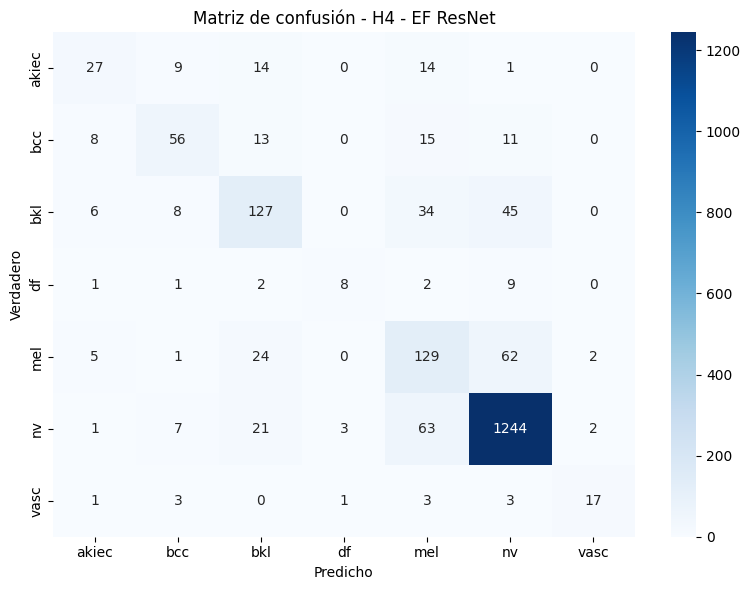

In [100]:
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, confusion_matrix)
import seaborn as sns

def eval_modelo(model, X_input, y_true_int, nombre):
    pred = model.predict(X_input, verbose=0)
    y_pred = pred.argmax(axis=1)
    acc = accuracy_score(y_true_int, y_pred)
    f1  = f1_score(y_true_int, y_pred, average='macro')
    print(f'\n━━━ {nombre} ━━━')
    print(f'Accuracy: {acc:.4f} | F1-macro: {f1:.4f}')
    print(classification_report(y_true_int, y_pred,
                                target_names=classes, zero_division=0))
    return {'nombre': nombre, 'acc': acc, 'f1': f1, 'y_pred': y_pred}

resultados = []
resultados.append(eval_modelo(tabular_model,  X_tab_test, y_test_int, 'H1 - Tabular'))
resultados.append(eval_modelo(vision_model_1, X_img_test, y_test_int, 'H2 - CNN manual'))
resultados.append(eval_modelo(vision_model_2, X_img_test, y_test_int, 'H2 - VGG16'))
resultados.append(eval_modelo(vision_model_3, X_img_test, y_test_int, 'H2 - ResNet50'))
resultados.append(eval_modelo(vision_model_4, X_img_test, y_test_int, 'H2 - InceptionV3'))
resultados.append(eval_modelo(model_lf_1, [X_tab_test, X_img_test], y_test_int, 'H3 - LF CNN'))
resultados.append(eval_modelo(model_lf_2, [X_tab_test, X_img_test], y_test_int, 'H3 - LF VGG'))
resultados.append(eval_modelo(model_lf_3, [X_tab_test, X_img_test], y_test_int, 'H3 - LF ResNet'))
resultados.append(eval_modelo(model_lf_4, [X_tab_test, X_img_test], y_test_int, 'H3 - LF Inception'))
resultados.append(eval_modelo(model_ef_1, [X_tab_test, X_img_test], y_test_int, 'H4 - EF CNN'))
resultados.append(eval_modelo(model_ef_2, [X_tab_test, X_img_test], y_test_int, 'H4 - EF VGG'))
resultados.append(eval_modelo(model_ef_3, [X_tab_test, X_img_test], y_test_int, 'H4 - EF ResNet'))
resultados.append(eval_modelo(model_ef_4, [X_tab_test, X_img_test], y_test_int, 'H4 - EF Inception'))

resumen = pd.DataFrame(
    [(r['nombre'], r['acc'], r['f1']) for r in resultados],
    columns=['Modelo', 'Accuracy', 'F1-macro']
).sort_values('F1-macro', ascending=False).reset_index(drop=True)
print('\n\n══════ TABLA COMPARATIVA ══════')
print(resumen.to_string(index=False))

mejor = max(resultados, key=lambda r: r['f1'])
cm = confusion_matrix(y_test_int, mejor['y_pred'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes,
            yticklabels=classes, cmap='Blues')
plt.title(f"Matriz de confusión - {mejor['nombre']}")
plt.ylabel('Verdadero'); plt.xlabel('Predicho')
plt.tight_layout()
plt.show()